# APX1145 Frequency-Drop Hypothesis Check

This notebook is intentionally focused on one question:

**Does the APX1145 power drop coincide with a frequency drop?**

It uses only detailed run artifacts (`turbostat` + `perf`) from the latest detailed collection run.

In [53]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

DATA_DIR = Path("logs/perf_detailed/detailed_perf_runs")

# Analyze these run IDs (add/remove IDs as needed).
RUN_IDS = [
    "35E294A526740733",
    "F9E601301987551E"
]

run_meta_files = {}
for rid in RUN_IDS:
    meta_files = sorted(DATA_DIR.glob(f"{rid}__detailed_perf_metadata.txt"), key=lambda p: p.stat().st_mtime)
    if not meta_files:
        raise FileNotFoundError(f"No detailed metadata files found for run_id={rid} under {DATA_DIR}")
    run_meta_files[rid] = meta_files[-1]

print("Run IDs to analyze:", RUN_IDS)
for rid in RUN_IDS:
    print(f"Using metadata for {rid}: {run_meta_files[rid].name}")

Run IDs to analyze: ['35E294A526740733', 'F9E601301987551E']
Using metadata for 35E294A526740733: 35E294A526740733__detailed_perf_metadata.txt
Using metadata for F9E601301987551E: F9E601301987551E__detailed_perf_metadata.txt


In [54]:
def parse_meta(path: Path) -> dict:
    meta = {}
    for line in path.read_text(encoding="utf-8").splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            meta[k.strip()] = v.strip()
    return meta


def parse_perf_file(path: Path) -> pd.DataFrame:
    cols = [
        "time_sec", "value", "unit", "event", "runtime_ns", "pct_running", "metric_value", "metric_unit"
    ]
    df = pd.read_csv(path, comment="#", header=None, names=cols)
    df = df.dropna(subset=["event", "value"]).copy()

    m = re.match(r"(?P<run_id>[A-F0-9]+)__(?P<query>.+)\.perf\.csv$", path.name)
    df["run_id"] = m.group("run_id") if m else "unknown"
    df["query"] = m.group("query") if m else path.stem
    df["file_name"] = path.name

    for col in ["time_sec", "value", "runtime_ns", "pct_running", "metric_value"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["sample_idx"] = df.groupby(["query", "file_name", "event"]).cumcount()
    return df


def parse_turbo_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    m = re.match(r"(?P<run_id>[A-F0-9]+)__(?P<query>.+)\.turbostat\.csv$", path.name)

    if "Core" in df.columns:
        df = df[df["Core"].astype(str) != "Core"].copy()

    df["run_id"] = m.group("run_id") if m else "unknown"
    df["query"] = m.group("query") if m else path.stem
    df["file_name"] = path.name

    num_cols = ["PkgWatt", "CorWatt", "RAMWatt", "PkgTmp", "CoreTmp", "Avg_MHz", "Bzy_MHz", "Busy%", "IPC", "TSC_MHz"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["Core_str"] = df.get("Core", pd.Series([np.nan] * len(df))).astype(str)
    df["CPU_str"] = df.get("CPU", pd.Series([np.nan] * len(df))).astype(str)

    package_mask = (df["Core_str"] == "-") & (df["CPU_str"] == "-")
    if package_mask.any():
        df["sample_id"] = package_mask.cumsum() - 1
    else:
        df["sample_id"] = np.arange(len(df))

    df["sample_id"] = pd.to_numeric(df["sample_id"], errors="coerce")
    return df


run_frames = []
for rid in RUN_IDS:
    meta = parse_meta(run_meta_files[rid])
    run_id = meta.get("run_id", rid)
    sample_interval_sec = int(meta.get("sample_interval_sec", "1") or 1)

    perf_files = sorted(DATA_DIR.glob(f"{run_id}__*.perf.csv"))
    turbo_files = sorted(DATA_DIR.glob(f"{run_id}__*.turbostat.csv"))

    if not perf_files or not turbo_files:
        raise FileNotFoundError(f"Run {run_id} does not have both perf and turbostat files")

    perf_df = pd.concat([parse_perf_file(p) for p in perf_files], ignore_index=True)
    turbo_df = pd.concat([parse_turbo_file(p) for p in turbo_files], ignore_index=True)
    turbo_df["time_s"] = turbo_df["sample_id"] * sample_interval_sec

    run_frames.append({
        "run_id": run_id,
        "sample_interval_sec": sample_interval_sec,
        "perf_df": perf_df,
        "turbo_df": turbo_df,
    })

print(f"Loaded {len(run_frames)} run(s)")
for frame in run_frames:
    print(
        f"run_id={frame['run_id']} | perf_rows={len(frame['perf_df']):,} | turbostat_rows={len(frame['turbo_df']):,} | interval={frame['sample_interval_sec']}s"
    )

Loaded 2 run(s)
run_id=35E294A526740733 | perf_rows=1,212 | turbostat_rows=909 | interval=1s
run_id=F9E601301987551E | perf_rows=1,668 | turbostat_rows=1,251 | interval=1s


In [55]:
def detect_drop_pos(series: pd.Series, min_frac: float = 0.2, window: int = 9) -> int:
    s = series.reset_index(drop=True).astype(float).dropna()
    n = len(s)
    if n < 20:
        return int(max(1, n // 2))

    smooth = s.rolling(window=window, min_periods=1, center=True).median().reset_index(drop=True)

    start = max(window, int(n * min_frac))
    end = min(n - window - 1, int(n * (1 - min_frac)))
    if end <= start:
        return int(n // 2)

    best_pos = start
    best_score = -np.inf
    for i in range(start, end + 1):
        pre_med = smooth.iloc[max(0, i - window):i].median()
        post_med = smooth.iloc[i:min(n, i + window)].median()
        score = pre_med - post_med
        if pd.notna(score) and score > best_score:
            best_score = score
            best_pos = i

    return int(best_pos)


run_results = []
for frame in run_frames:
    run_id = frame["run_id"]
    sample_interval_sec = frame["sample_interval_sec"]
    turbo_df = frame["turbo_df"]

    pkg = turbo_df[(turbo_df["Core_str"] == "-") & (turbo_df["CPU_str"] == "-")].copy()
    if pkg.empty:
        use_cols = [c for c in ["PkgWatt", "Avg_MHz", "Bzy_MHz", "Busy%", "IPC"] if c in turbo_df.columns]
        pkg = turbo_df.groupby(["query", "sample_id"], as_index=False)[use_cols].median()
    else:
        pkg = pkg.sort_values(["query", "sample_id"]).copy()

    pkg["time_s"] = pkg["sample_id"] * sample_interval_sec

    drop_points = {}
    for query, g in pkg.groupby("query"):
        g = g.sort_values("sample_id").reset_index(drop=True)
        if "PkgWatt" in g.columns and g["PkgWatt"].notna().sum() > 0:
            pos = detect_drop_pos(g["PkgWatt"])
            drop_points[query] = int(g.loc[pos, "sample_id"])
        else:
            drop_points[query] = int(g["sample_id"].median())

    pkg["phase"] = "pre-drop"
    for query, sample_cut in drop_points.items():
        mask = (pkg["query"] == query) & (pkg["sample_id"] >= sample_cut)
        pkg.loc[mask, "phase"] = "post-drop"

    run_results.append({
        "run_id": run_id,
        "sample_interval_sec": sample_interval_sec,
        "turbo_df": turbo_df,
        "pkg": pkg,
        "drop_points": drop_points,
    })

for result in run_results:
    print(f"run_id={result['run_id']} drop points (sample_id): {result['drop_points']}")
    display(result["pkg"].groupby(["query", "phase"], as_index=False).size())

run_id=35E294A526740733 drop points (sample_id): {'APX1145-queryA.sql': 46, 'APX1145-queryB.sql': 30}


,query,phase,size
0,APX1145-queryA.sql,post-drop,12
1,APX1145-queryA.sql,pre-drop,46
2,APX1145-queryB.sql,post-drop,13
3,APX1145-queryB.sql,pre-drop,30


run_id=F9E601301987551E drop points (sample_id): {'APX1186-queryA.sql': 78, 'APX1186-queryB.sql': 25}


,query,phase,size
0,APX1186-queryA.sql,post-drop,21
1,APX1186-queryA.sql,pre-drop,78
2,APX1186-queryB.sql,post-drop,15
3,APX1186-queryB.sql,pre-drop,25


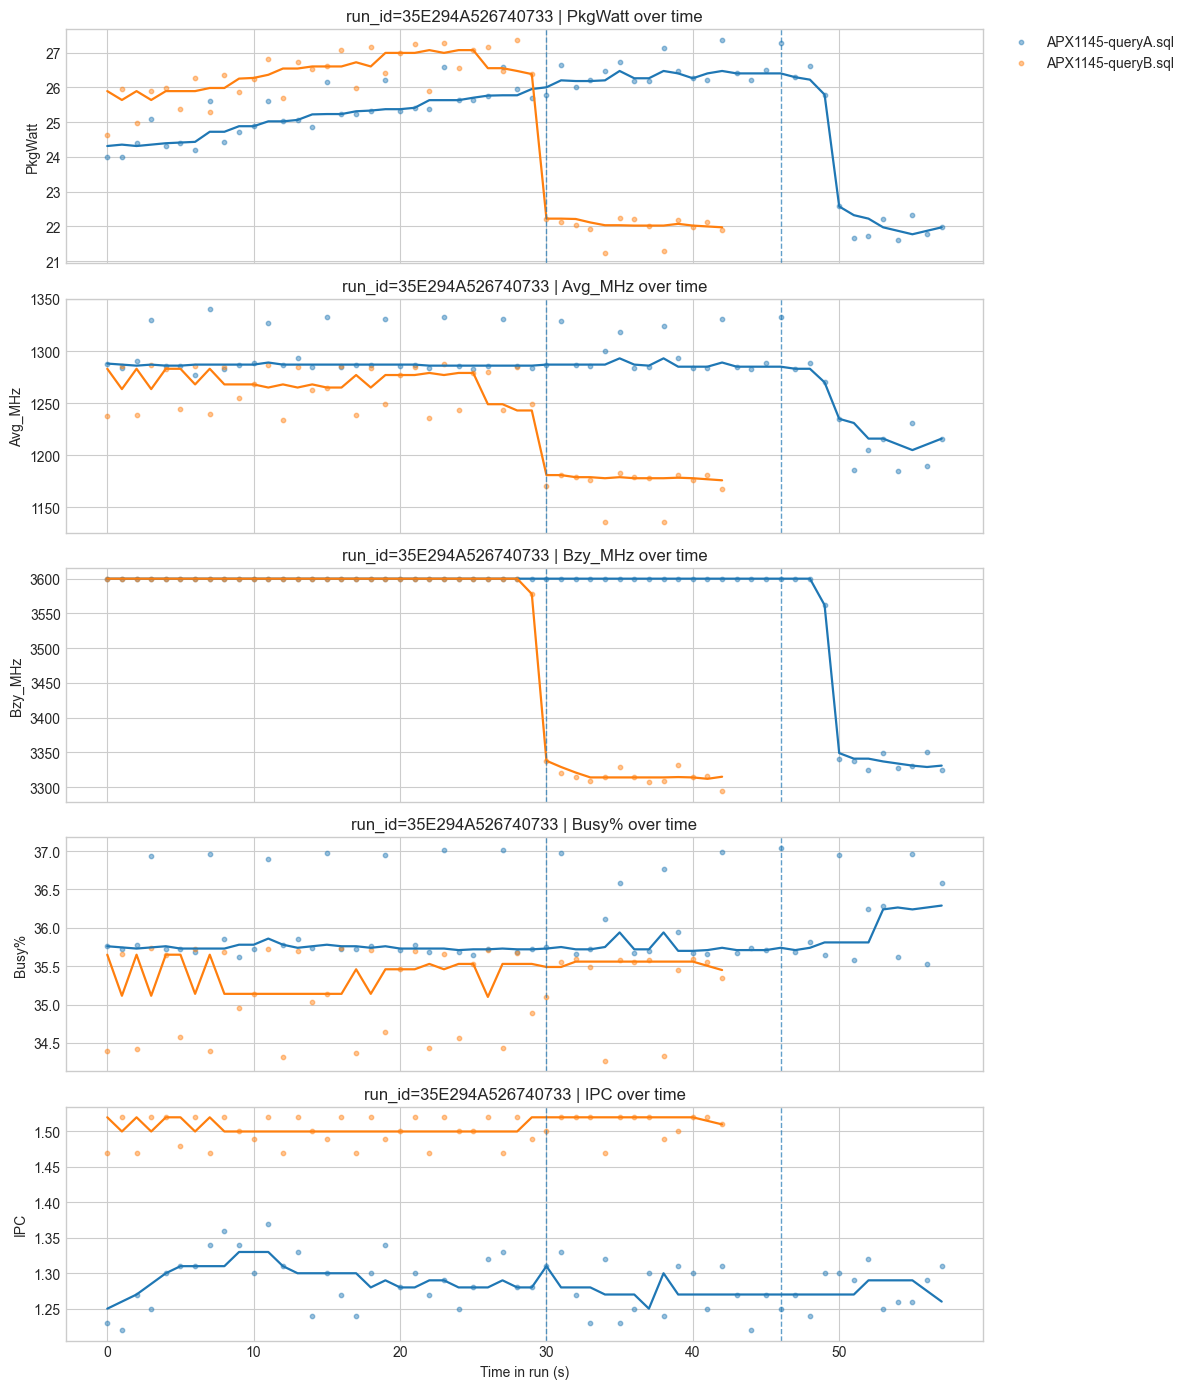

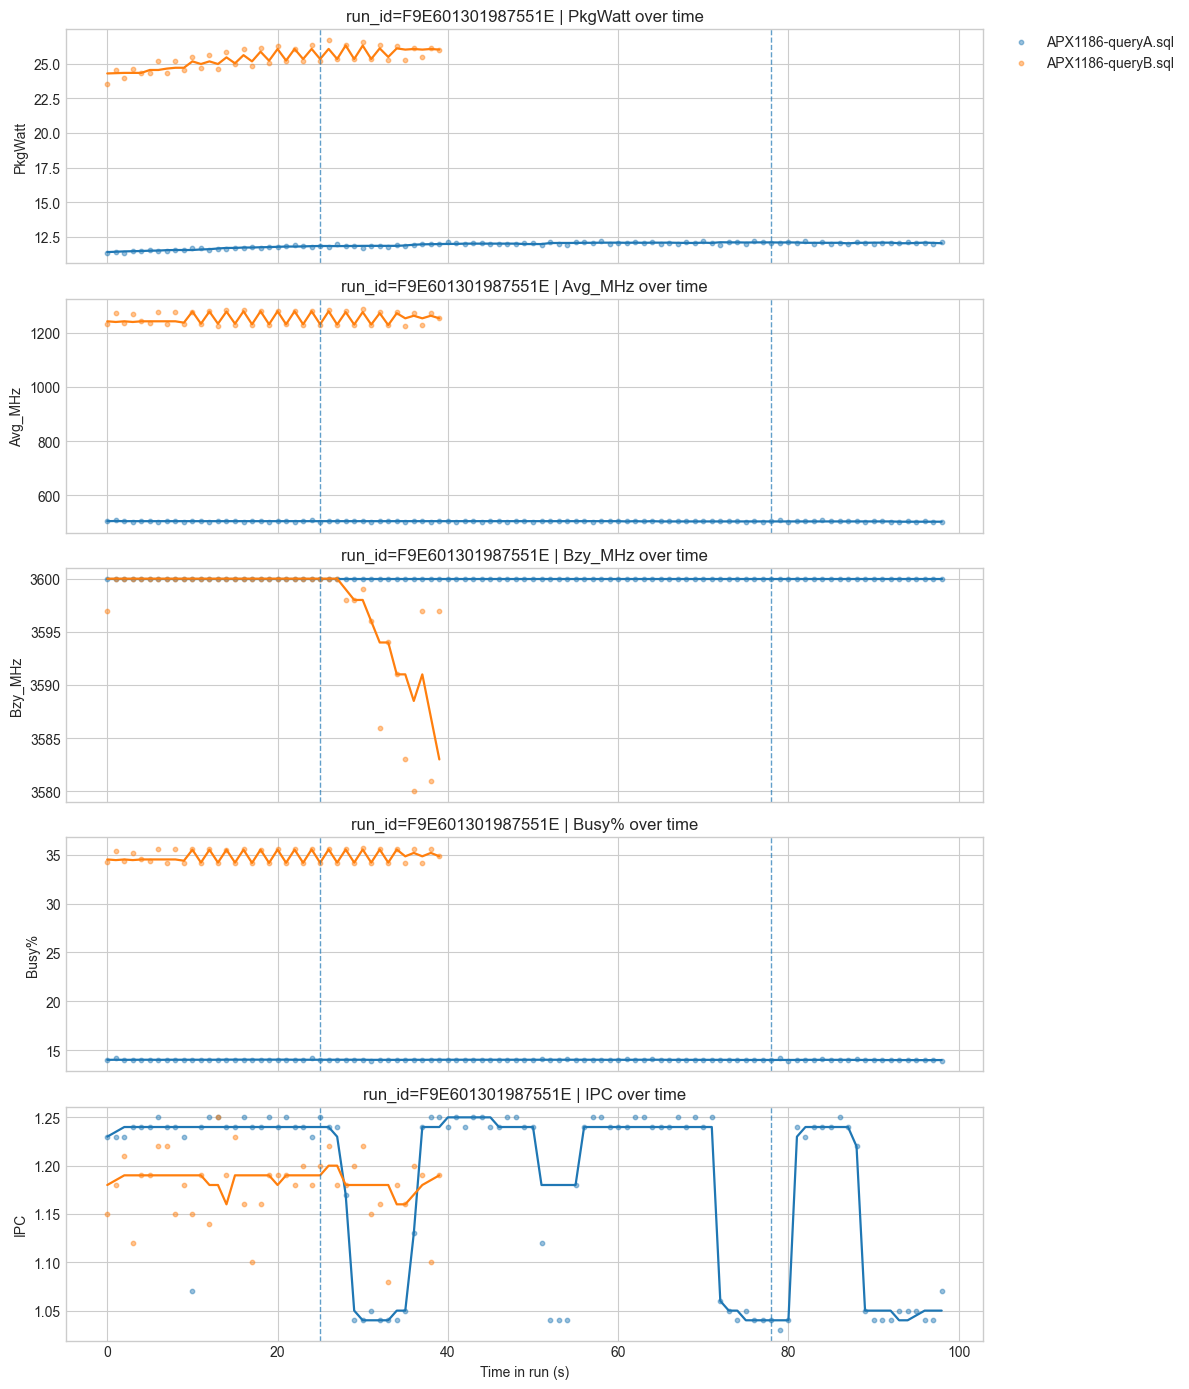

In [56]:
# Plot 1: Package-level signals over time around the detected drop point, per run ID.
for result in run_results:
    run_id = result["run_id"]
    pkg = result["pkg"]
    drop_points = result["drop_points"]
    sample_interval_sec = result["sample_interval_sec"]

    plot_cols = [c for c in ["PkgWatt", "Avg_MHz", "Bzy_MHz", "Busy%", "IPC"] if c in pkg.columns]
    if not plot_cols:
        print(f"run_id={run_id}: no package-level metrics available for plotting")
        continue

    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, max(4, 2.8 * len(plot_cols))), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]

    for ax, metric in zip(axes, plot_cols):
        for query, g in pkg.groupby("query"):
            g = g.sort_values("sample_id")
            ax.scatter(g["time_s"], g[metric], s=10, alpha=0.45, label=query)
            ax.plot(g["time_s"], g[metric].rolling(9, min_periods=1, center=True).median(), linewidth=1.6)

            drop_idx = drop_points.get(query)
            if drop_idx is not None:
                drop_time = float(drop_idx * sample_interval_sec)
                ax.axvline(drop_time, linestyle="--", linewidth=1, alpha=0.7)

        ax.set_ylabel(metric)
        ax.set_title(f"run_id={run_id} | {metric} over time")

    axes[-1].set_xlabel("Time in run (s)")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

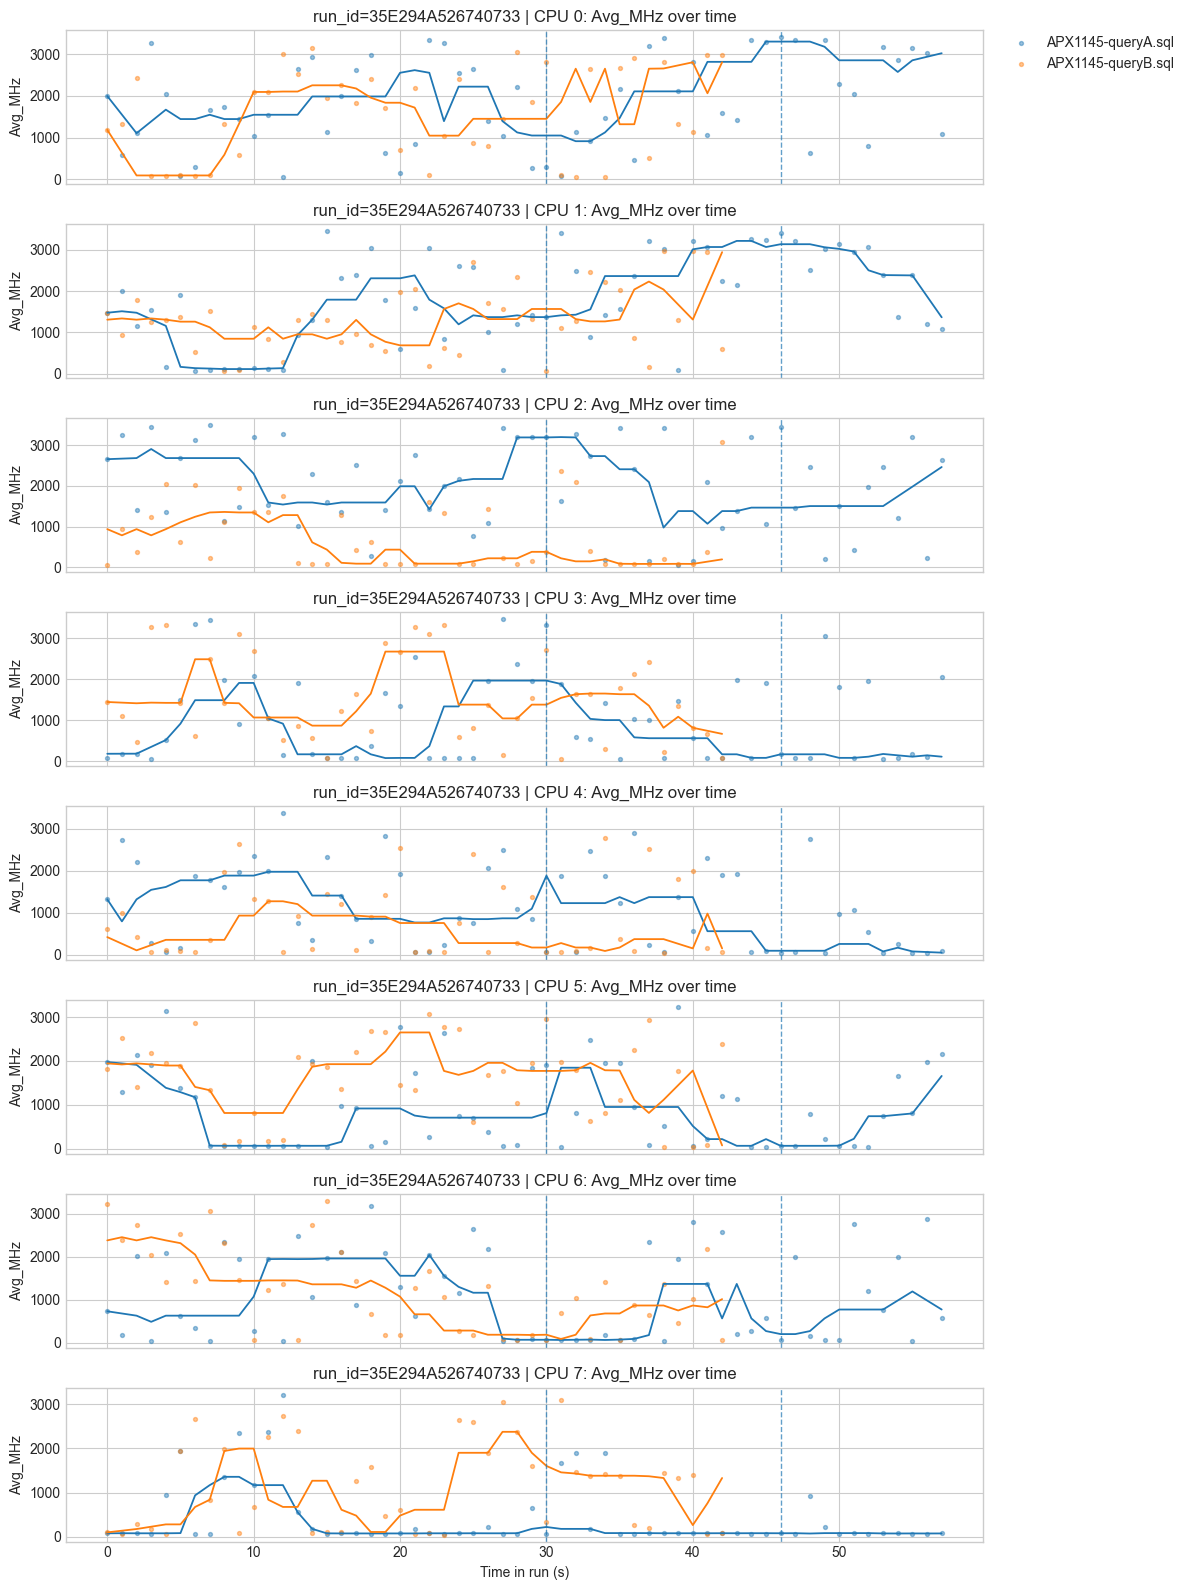

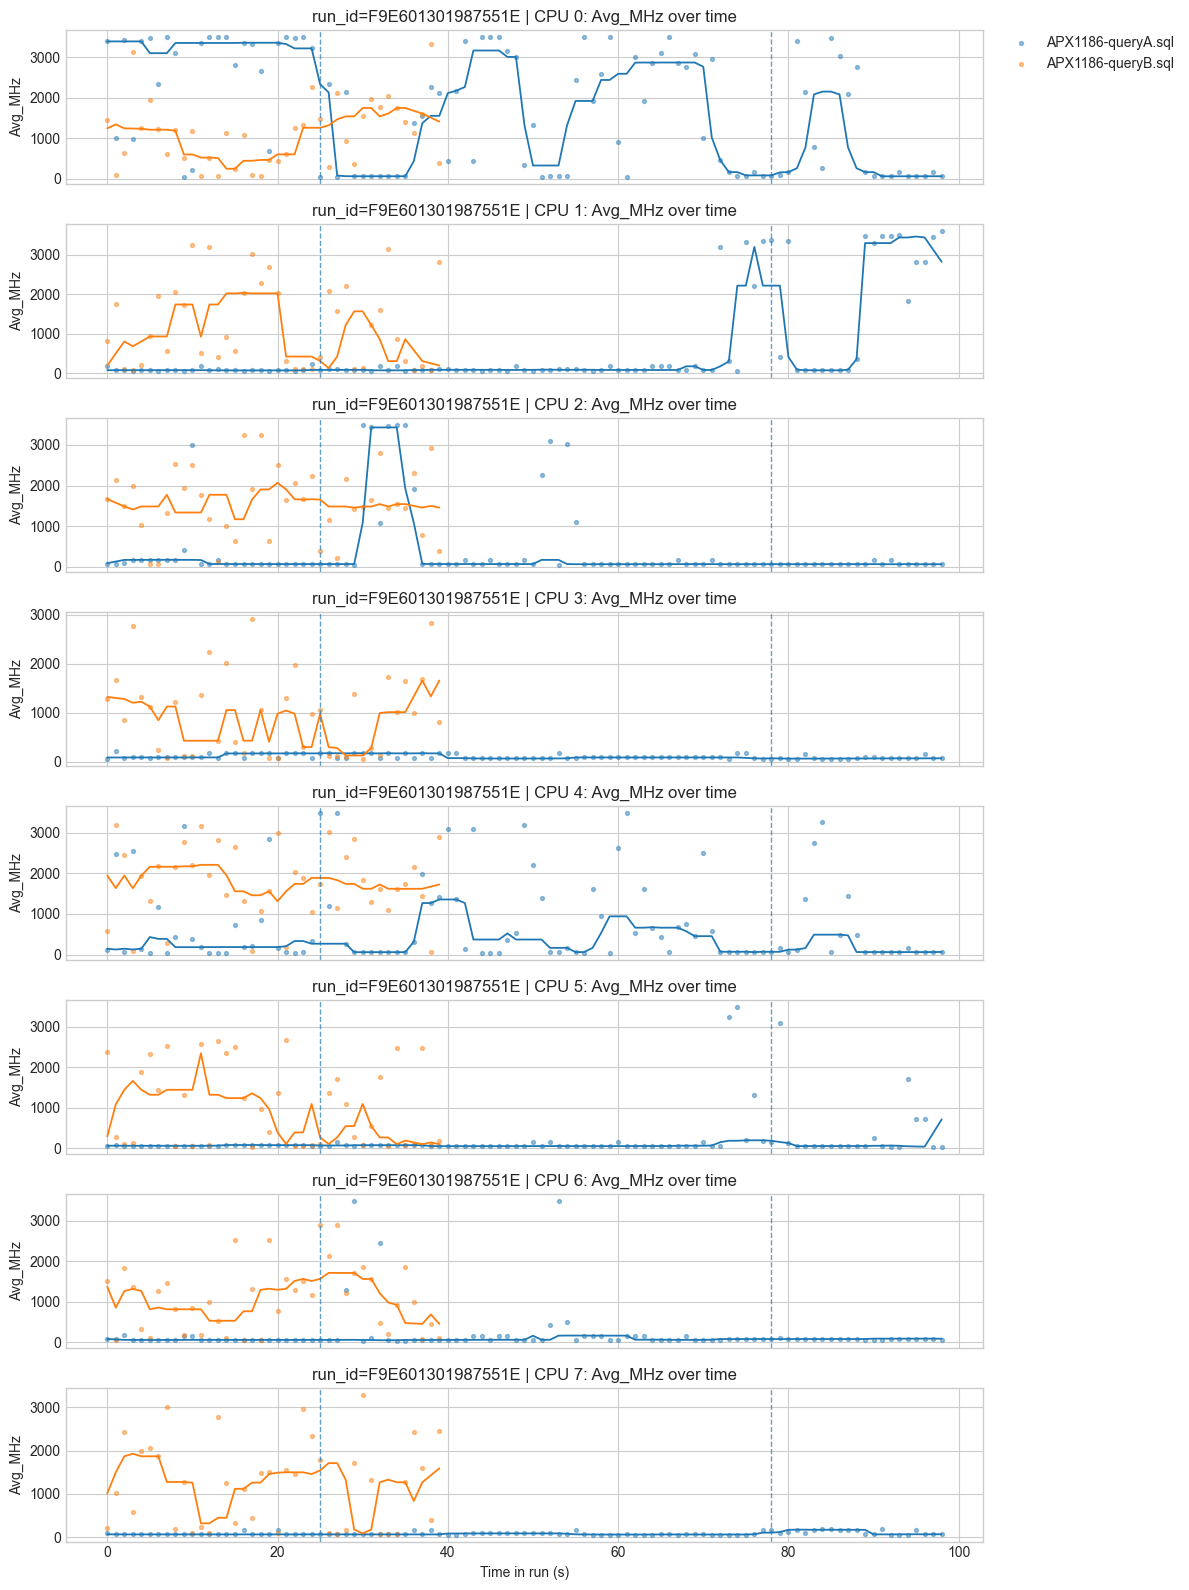

In [57]:
# Plot 2: Per-CPU Avg_MHz over time, per run ID.
for result in run_results:
    run_id = result["run_id"]
    turbo_df = result["turbo_df"]
    drop_points = result["drop_points"]
    sample_interval_sec = result["sample_interval_sec"]

    cpu_df = turbo_df.copy()
    cpu_df["cpu_id"] = pd.to_numeric(cpu_df["CPU_str"], errors="coerce")
    cpu_df = cpu_df.dropna(subset=["cpu_id"]).copy()
    cpu_df["cpu_id"] = cpu_df["cpu_id"].astype(int)

    if "Avg_MHz" not in cpu_df.columns or cpu_df["Avg_MHz"].notna().sum() == 0:
        print(f"run_id={run_id}: Avg_MHz not available in per-CPU rows")
        continue

    cpu_df["time_s"] = cpu_df["sample_id"] * sample_interval_sec
    cpus = sorted(cpu_df["cpu_id"].unique())

    fig, axes = plt.subplots(len(cpus), 1, figsize=(12, max(4, 2.0 * len(cpus))), sharex=True)
    if len(cpus) == 1:
        axes = [axes]

    for ax, cpu in zip(axes, cpus):
        cdf = cpu_df[cpu_df["cpu_id"] == cpu].sort_values("sample_id")
        for query, g in cdf.groupby("query"):
            ax.scatter(g["time_s"], g["Avg_MHz"], s=8, alpha=0.45, label=query)
            ax.plot(g["time_s"], g["Avg_MHz"].rolling(9, min_periods=1, center=True).median(), linewidth=1.3)

            if query in drop_points:
                ax.axvline(drop_points[query] * sample_interval_sec, linestyle="--", linewidth=1, alpha=0.7)

        ax.set_title(f"run_id={run_id} | CPU {cpu}: Avg_MHz over time")
        ax.set_ylabel("Avg_MHz")

    axes[-1].set_xlabel("Time in run (s)")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

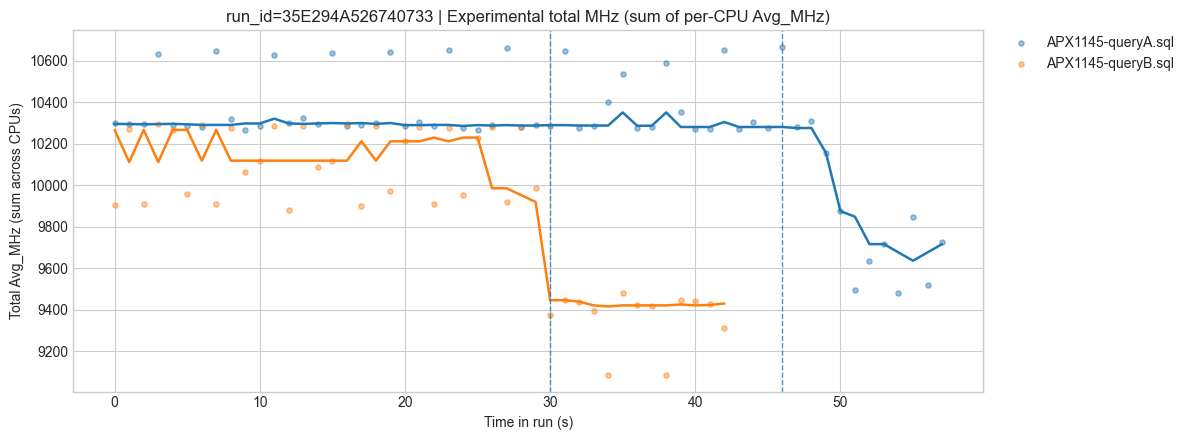

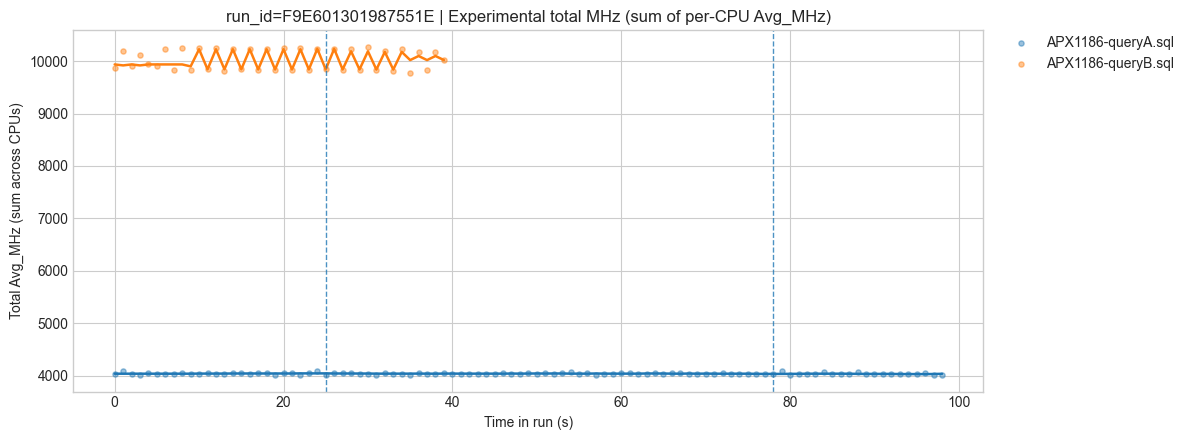

In [58]:
# Experimental plot: total Avg_MHz across all CPUs per sample (per run/query)
for result in run_results:
    run_id = result["run_id"]
    turbo_df = result["turbo_df"].copy()
    drop_points = result["drop_points"]
    sample_interval_sec = result["sample_interval_sec"]

    turbo_df["cpu_id"] = pd.to_numeric(turbo_df["CPU_str"], errors="coerce")
    cpu_df = turbo_df.dropna(subset=["cpu_id"]).copy()

    if "Avg_MHz" not in cpu_df.columns or cpu_df["Avg_MHz"].notna().sum() == 0:
        print(f"run_id={run_id}: Avg_MHz not available")
        continue

    total_mhz = (
        cpu_df.groupby(["query", "sample_id"], as_index=False)["Avg_MHz"]
        .sum()
        .rename(columns={"Avg_MHz": "Total_Avg_MHz"})
    )
    total_mhz["time_s"] = total_mhz["sample_id"] * sample_interval_sec

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for query, g in total_mhz.groupby("query"):
        g = g.sort_values("sample_id")
        ax.scatter(g["time_s"], g["Total_Avg_MHz"], s=14, alpha=0.45, label=query)
        ax.plot(
            g["time_s"],
            g["Total_Avg_MHz"].rolling(9, min_periods=1, center=True).median(),
            linewidth=1.8
        )

        if query in drop_points:
            ax.axvline(drop_points[query] * sample_interval_sec, linestyle="--", linewidth=1, alpha=0.8)

    ax.set_title(f"run_id={run_id} | Experimental total MHz (sum of per-CPU Avg_MHz)")
    ax.set_xlabel("Time in run (s)")
    ax.set_ylabel("Total Avg_MHz (sum across CPUs)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    plt.tight_layout()
    plt.show()